# SARIMA Alternative Paths Notebook

This notebook keeps the exploratory alternative branch: decomposition into separate Load/Wind/Solar models and reconstruction of net demand.

It is intentionally separated from the core notebook to keep both narratives clear.

# Step 5: Three-Model Decomposition (Load, Wind, Solar)

Net demand is reconstructed as:
**Net_demand = Load - Solar_power - Wind_power**

This branch is kept to document an alternative modeling direction explored in the project.

## Step 1: Data Checks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# Load data
train_path = '../Data/train.csv'
test_path = '../Data/test.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# Convert Date to datetime
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

# Sort by date (CRITICAL)
train = train.sort_values('Date').reset_index(drop=True)
test = test.sort_values('Date').reset_index(drop=True)

## Step 5.1: Data Checks and Validity

### 5.1.1 Load Forecasting Branch

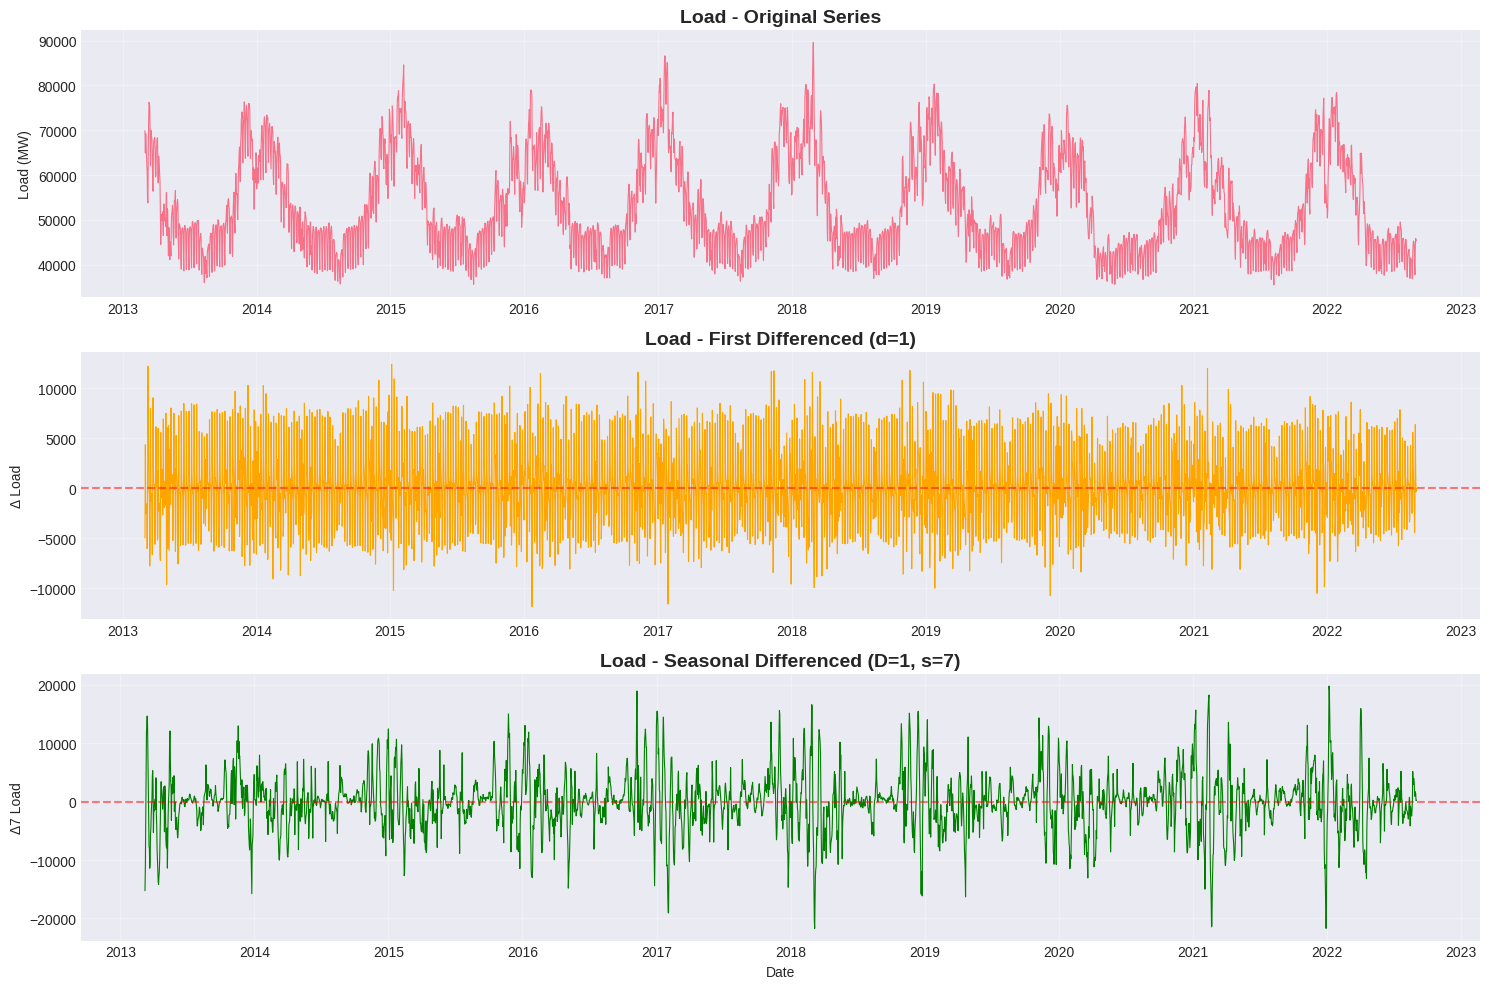

In [3]:
# Plot Load series
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Original series
axes[0].plot(train['Date'], train['Load'], linewidth=0.8)
axes[0].set_title('Load - Original Series', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Load (MW)')
axes[0].grid(True, alpha=0.3)

# First difference (d=1)
load_diff1 = train['Load'].diff().dropna()
axes[1].plot(train['Date'].iloc[1:], load_diff1, linewidth=0.8, color='orange')
axes[1].set_title('Load - First Differenced (d=1)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Δ Load')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

# Seasonal difference (D=1, s=7)
load_diff7 = train['Load'].diff(7).dropna()
axes[2].plot(train['Date'].iloc[7:], load_diff7, linewidth=0.8, color='green')
axes[2].set_title('Load - Seasonal Differenced (D=1, s=7)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Δ7 Load')
axes[2].set_xlabel('Date')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# ADF tests for Load
def run_stationarity_tests(series, name):
    """Run ADF"""
    print(f"\n{'=' * 80}")
    print(f"STATIONARITY TESTS: {name}")
    print('=' * 80)
    
    # ADF test (H0: non-stationary)
    adf_result = adfuller(series.dropna(), autolag='AIC')
    print(f"\nAugmented Dickey-Fuller Test:")
    print(f"  ADF Statistic: {adf_result[0]:.6f}")
    print(f"  p-value: {adf_result[1]:.6f}")
    print(f"  Critical values:")
    for key, value in adf_result[4].items():
        print(f"    {key}: {value:.6f}")
    
    adf_stationary = adf_result[1] < 0.05
    print(f"  => {'o STATIONARY' if adf_stationary else 'x NON-STATIONARY'} (p={'<' if adf_stationary else '>'} 0.05)")

    # Conclusion
    print(f"\n{'─' * 80}")
    print("CONCLUSION:")
    if adf_stationary:
        print("  Test indicate STATIONARITY")
        conclusion = "stationary"
    else:
        print("  Test indicate NON-STATIONARITY")
        conclusion = "non-stationary"
    print('─' * 80)
    
    return adf_stationary, conclusion

# Test original Load
adf_load, conclusion_load = run_stationarity_tests(train['Load'], 'Load (Original)')

# Test differenced Load (d=1)
adf_load_d1, conclusion_load_d1 = run_stationarity_tests(train['Load'].diff(), 'Load (d=1)')

# Test seasonally differenced Load (D=1, s=7)
adf_load_D1, conclusion_load_D1 = run_stationarity_tests(train['Load'].diff(7), 'Load (D=1, s=7)')

# Test both differences (d=1, D=1)
load_diff_both = train['Load'].diff().diff(7)
adf_load_both, conclusion_load_both = run_stationarity_tests(load_diff_both, 'Load (d=1, D=1, s=7)')


STATIONARITY TESTS: Load (Original)

Augmented Dickey-Fuller Test:
  ADF Statistic: -4.246197
  p-value: 0.000550
  Critical values:
    1%: -3.432252
    5%: -2.862381
    10%: -2.567217
  => o STATIONARY (p=< 0.05)

────────────────────────────────────────────────────────────────────────────────
CONCLUSION:
  Test indicate STATIONARITY
────────────────────────────────────────────────────────────────────────────────

STATIONARITY TESTS: Load (d=1)

Augmented Dickey-Fuller Test:
  ADF Statistic: -11.514410
  p-value: 0.000000
  Critical values:
    1%: -3.432253
    5%: -2.862381
    10%: -2.567218
  => o STATIONARY (p=< 0.05)

────────────────────────────────────────────────────────────────────────────────
CONCLUSION:
  Test indicate STATIONARITY
────────────────────────────────────────────────────────────────────────────────

STATIONARITY TESTS: Load (D=1, s=7)

Augmented Dickey-Fuller Test:
  ADF Statistic: -10.116017
  p-value: 0.000000
  Critical values:
    1%: -3.432256
    5%:

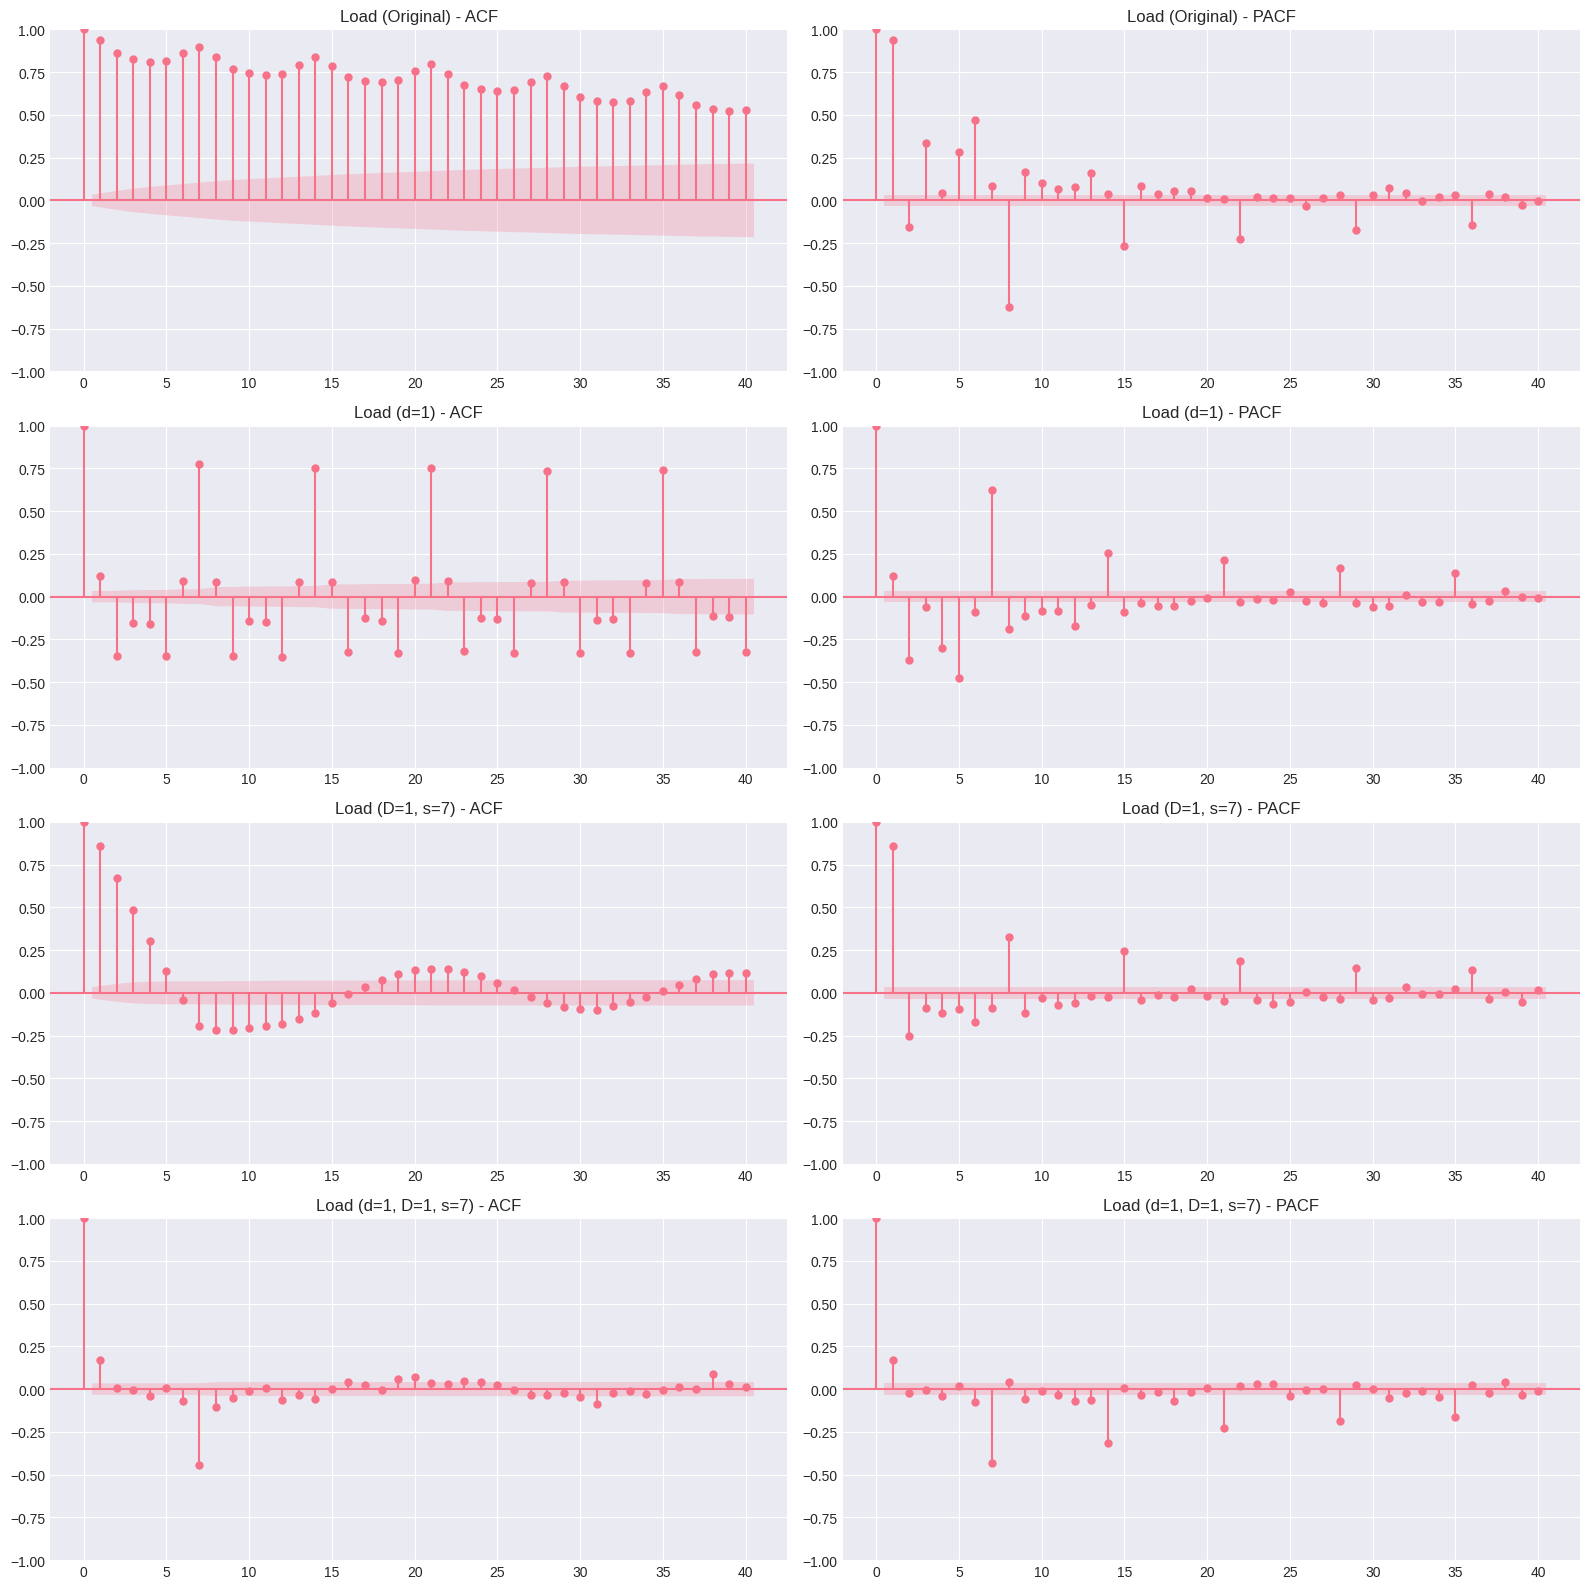

In [5]:
# ACF and PACF plots for Load
fig, axes = plt.subplots(4, 2, figsize=(16, 16))

# Original series
plot_acf(train['Load'].dropna(), ax=axes[0, 0], lags=40, title='Load (Original) - ACF')
plot_pacf(train['Load'].dropna(), ax=axes[0, 1], lags=40, title='Load (Original) - PACF', method='ywm')

# First difference (d=1)
plot_acf(train['Load'].diff().dropna(), ax=axes[1, 0], lags=40, title='Load (d=1) - ACF')
plot_pacf(train['Load'].diff().dropna(), ax=axes[1, 1], lags=40, title='Load (d=1) - PACF', method='ywm')

# Seasonal difference (D=1, s=7)
plot_acf(train['Load'].diff(7).dropna(), ax=axes[2, 0], lags=40, title='Load (D=1, s=7) - ACF')
plot_pacf(train['Load'].diff(7).dropna(), ax=axes[2, 1], lags=40, title='Load (D=1, s=7) - PACF', method='ywm')

# Both differences (d=1, D=1, s=7)
plot_acf(train['Load'].diff().diff(7).dropna(), ax=axes[3, 0], lags=40, title='Load (d=1, D=1, s=7) - ACF')
plot_pacf(train['Load'].diff().diff(7).dropna(), ax=axes[3, 1], lags=40, title='Load (d=1, D=1, s=7) - PACF', method='ywm')

plt.tight_layout()
plt.show()

In [6]:
# Decision for Load: d and D
print("\n" + "=" * 80)
print("DIFFERENCING DECISION FOR LOAD")
print("=" * 80)

print("\nSummary of stationarity tests:")
print(f"  Original (d=0, D=0): {conclusion_load}")
print(f"  First diff (d=1): {conclusion_load_d1}")
print(f"  Seasonal diff (D=1): {conclusion_load_D1}")
print(f"  Both (d=1, D=1): {conclusion_load_both}")

print("\n" + "-" * 80)
print("RECOMMENDATION:")
print("-" * 80)

# Based on the tests, make a recommendation
if conclusion_load == "stationary":
    print("  Load appears stationary => d=0, D=0")
    d_load_rec = 0
    D_load_rec = 0
elif conclusion_load_d1 == "stationary" and conclusion_load_D1 != "stationary":
    print("  First differencing achieves stationarity => d=1, D=0")
    d_load_rec = 1
    D_load_rec = 0
elif conclusion_load_D1 == "stationary" and conclusion_load_d1 != "stationary":
    print("  Seasonal differencing achieves stationarity => d=0, D=1")
    d_load_rec = 0
    D_load_rec = 1
elif conclusion_load_both == "stationary":
    print("  Both differencing needed => d=1, D=1")
    print("  WARNING: This may lead to over-differencing. Check ACF plots carefully.")
    d_load_rec = 1
    D_load_rec = 1
else:
    print("  Tests are inconclusive. Based on typical load patterns:")
    print("  Load usually shows weekly seasonality and trend => d=1, D=1")
    d_load_rec = 1
    D_load_rec = 1

print(f"\n  CHOSEN FOR LOAD: d={d_load_rec}, D={D_load_rec}, s=7")
print("=" * 80)


DIFFERENCING DECISION FOR LOAD

Summary of stationarity tests:
  Original (d=0, D=0): stationary
  First diff (d=1): stationary
  Seasonal diff (D=1): stationary
  Both (d=1, D=1): stationary

--------------------------------------------------------------------------------
RECOMMENDATION:
--------------------------------------------------------------------------------
  Load appears stationary => d=0, D=0

  CHOSEN FOR LOAD: d=0, D=0, s=7


### 2.2 Wind Power Forecasting

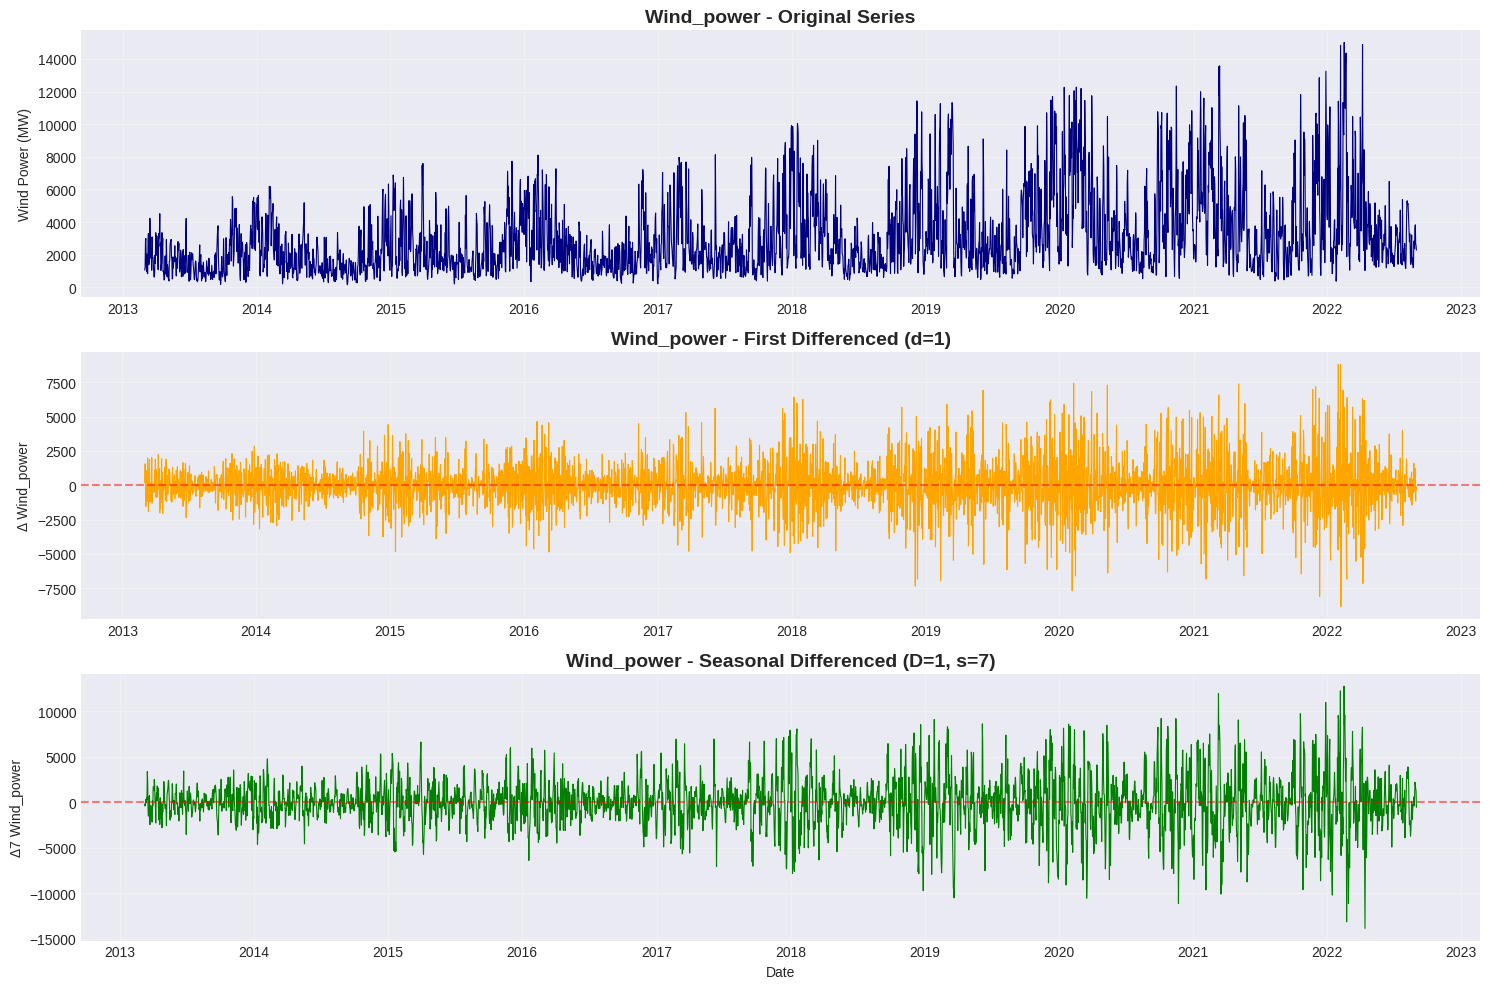

In [7]:
# Plot Wind_power series
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Original series
axes[0].plot(train['Date'], train['Wind_power'], linewidth=0.8, color='navy')
axes[0].set_title('Wind_power - Original Series', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Wind Power (MW)')
axes[0].grid(True, alpha=0.3)

# First difference (d=1)
wind_diff1 = train['Wind_power'].diff().dropna()
axes[1].plot(train['Date'].iloc[1:], wind_diff1, linewidth=0.8, color='orange')
axes[1].set_title('Wind_power - First Differenced (d=1)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Δ Wind_power')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

# Seasonal difference (D=1, s=7)
wind_diff7 = train['Wind_power'].diff(7).dropna()
axes[2].plot(train['Date'].iloc[7:], wind_diff7, linewidth=0.8, color='green')
axes[2].set_title('Wind_power - Seasonal Differenced (D=1, s=7)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Δ7 Wind_power')
axes[2].set_xlabel('Date')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# ADF test for Wind_power
adf_wind, conclusion_wind = run_stationarity_tests(train['Wind_power'], 'Wind_power (Original)')
adf_wind_d1, conclusion_wind_d1 = run_stationarity_tests(train['Wind_power'].diff(), 'Wind_power (d=1)')
adf_wind_D1, conclusion_wind_D1 = run_stationarity_tests(train['Wind_power'].diff(7), 'Wind_power (D=1, s=7)')
wind_diff_both = train['Wind_power'].diff().diff(7)
adf_wind_both, conclusion_wind_both = run_stationarity_tests(wind_diff_both, 'Wind_power (d=1, D=1, s=7)')


STATIONARITY TESTS: Wind_power (Original)



Augmented Dickey-Fuller Test:
  ADF Statistic: -5.449852
  p-value: 0.000003
  Critical values:
    1%: -3.432249
    5%: -2.862379
    10%: -2.567217
  => o STATIONARY (p=< 0.05)

────────────────────────────────────────────────────────────────────────────────
CONCLUSION:
  Test indicate STATIONARITY
────────────────────────────────────────────────────────────────────────────────

STATIONARITY TESTS: Wind_power (d=1)

Augmented Dickey-Fuller Test:
  ADF Statistic: -17.998005
  p-value: 0.000000
  Critical values:
    1%: -3.432251
    5%: -2.862380
    10%: -2.567217
  => o STATIONARY (p=< 0.05)

────────────────────────────────────────────────────────────────────────────────
CONCLUSION:
  Test indicate STATIONARITY
────────────────────────────────────────────────────────────────────────────────

STATIONARITY TESTS: Wind_power (D=1, s=7)

Augmented Dickey-Fuller Test:
  ADF Statistic: -16.093715
  p-value: 0.000000
  Critical values:
    1%: -3.432255
    5%: -2.862382
    10%: -2.56

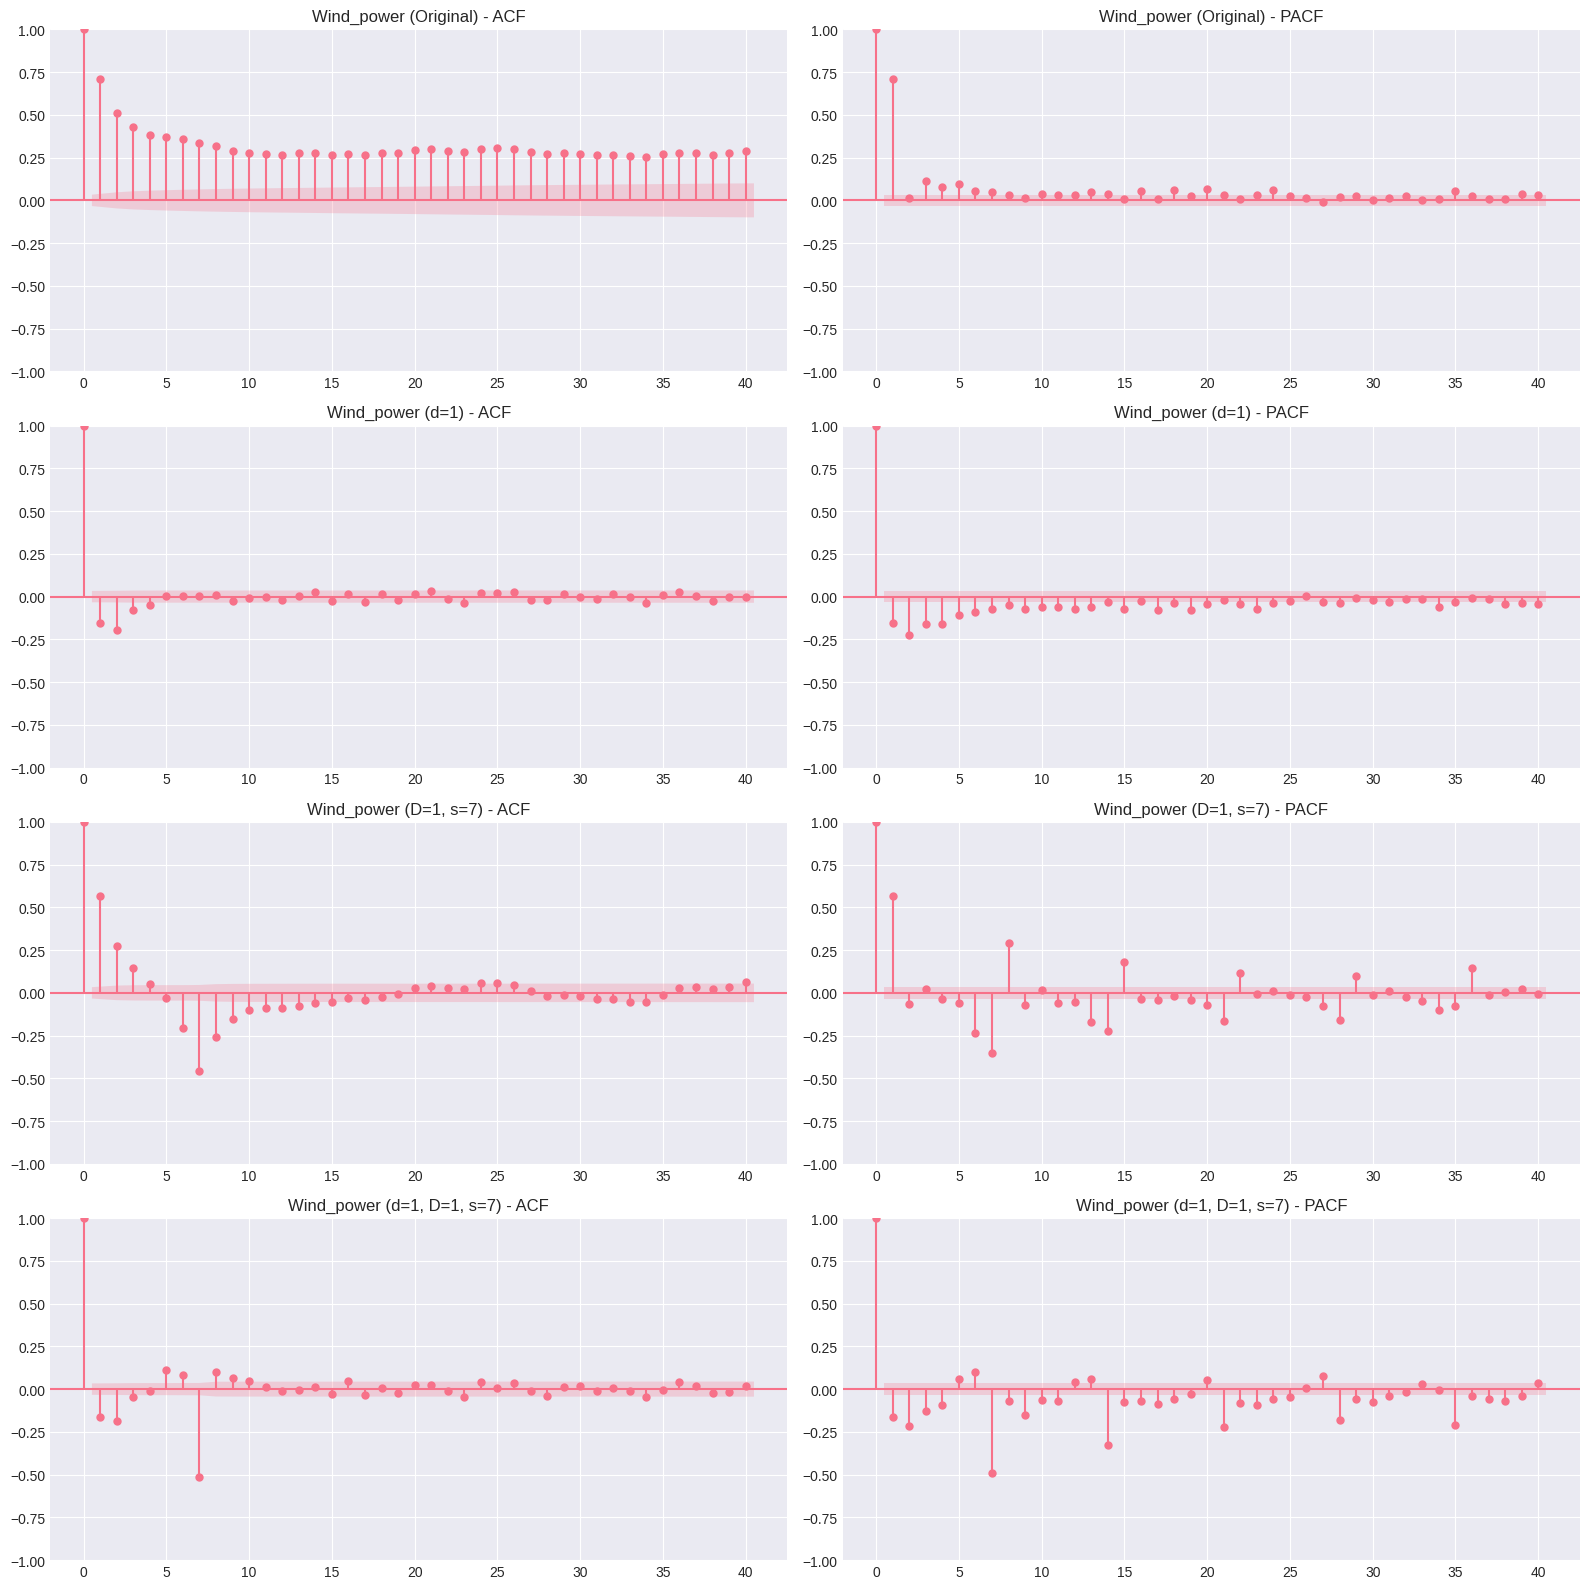

In [9]:
# ACF and PACF plots for Wind_power
fig, axes = plt.subplots(4, 2, figsize=(16, 16))

# Original series
plot_acf(train['Wind_power'].dropna(), ax=axes[0, 0], lags=40, title='Wind_power (Original) - ACF')
plot_pacf(train['Wind_power'].dropna(), ax=axes[0, 1], lags=40, title='Wind_power (Original) - PACF', method='ywm')

# First difference (d=1)
plot_acf(train['Wind_power'].diff().dropna(), ax=axes[1, 0], lags=40, title='Wind_power (d=1) - ACF')
plot_pacf(train['Wind_power'].diff().dropna(), ax=axes[1, 1], lags=40, title='Wind_power (d=1) - PACF', method='ywm')

# Seasonal difference (D=1, s=7)
plot_acf(train['Wind_power'].diff(7).dropna(), ax=axes[2, 0], lags=40, title='Wind_power (D=1, s=7) - ACF')
plot_pacf(train['Wind_power'].diff(7).dropna(), ax=axes[2, 1], lags=40, title='Wind_power (D=1, s=7) - PACF', method='ywm')

# Both differences (d=1, D=1, s=7)
plot_acf(train['Wind_power'].diff().diff(7).dropna(), ax=axes[3, 0], lags=40, title='Wind_power (d=1, D=1, s=7) - ACF')
plot_pacf(train['Wind_power'].diff().diff(7).dropna(), ax=axes[3, 1], lags=40, title='Wind_power (d=1, D=1, s=7) - PACF', method='ywm')

plt.tight_layout()
plt.show()

In [10]:
# Decision for Wind_power: d and D
print("\n" + "=" * 80)
print("DIFFERENCING DECISION FOR WIND_POWER")
print("=" * 80)

print("\nSummary of stationarity tests:")
print(f"  Original (d=0, D=0): {conclusion_wind}")
print(f"  First diff (d=1): {conclusion_wind_d1}")
print(f"  Seasonal diff (D=1): {conclusion_wind_D1}")
print(f"  Both (d=1, D=1): {conclusion_wind_both}")

print("\n" + "-" * 80)
print("RECOMMENDATION:")
print("-" * 80)

if conclusion_wind == "stationary":
    print("  Wind_power appears stationary => d=0, D=0")
    d_wind_rec = 0
    D_wind_rec = 0
elif conclusion_wind_d1 == "stationary" and conclusion_wind_D1 != "stationary":
    print("  First differencing achieves stationarity => d=1, D=0")
    d_wind_rec = 1
    D_wind_rec = 0
elif conclusion_wind_D1 == "stationary" and conclusion_wind_d1 != "stationary":
    print("  Seasonal differencing achieves stationarity => d=0, D=1")
    d_wind_rec = 0
    D_wind_rec = 1
elif conclusion_wind_both == "stationary":
    print("  Both differencing needed => d=1, D=1")
    print("  WARNING: Check for over-differencing in ACF plots.")
    d_wind_rec = 1
    D_wind_rec = 1
else:
    print("  Tests are inconclusive. Wind power is often volatile:")
    print("  Trying d=0, D=0 first (stationarity may exist naturally)")
    d_wind_rec = 0
    D_wind_rec = 0

print(f"\n  ok CHOSEN FOR WIND_POWER: d={d_wind_rec}, D={D_wind_rec}, s=7")
print("=" * 80)


DIFFERENCING DECISION FOR WIND_POWER

Summary of stationarity tests:
  Original (d=0, D=0): stationary
  First diff (d=1): stationary
  Seasonal diff (D=1): stationary
  Both (d=1, D=1): stationary

--------------------------------------------------------------------------------
RECOMMENDATION:
--------------------------------------------------------------------------------
  Wind_power appears stationary => d=0, D=0

  ok CHOSEN FOR WIND_POWER: d=0, D=0, s=7


### 2.3 Solar Power Forecasting

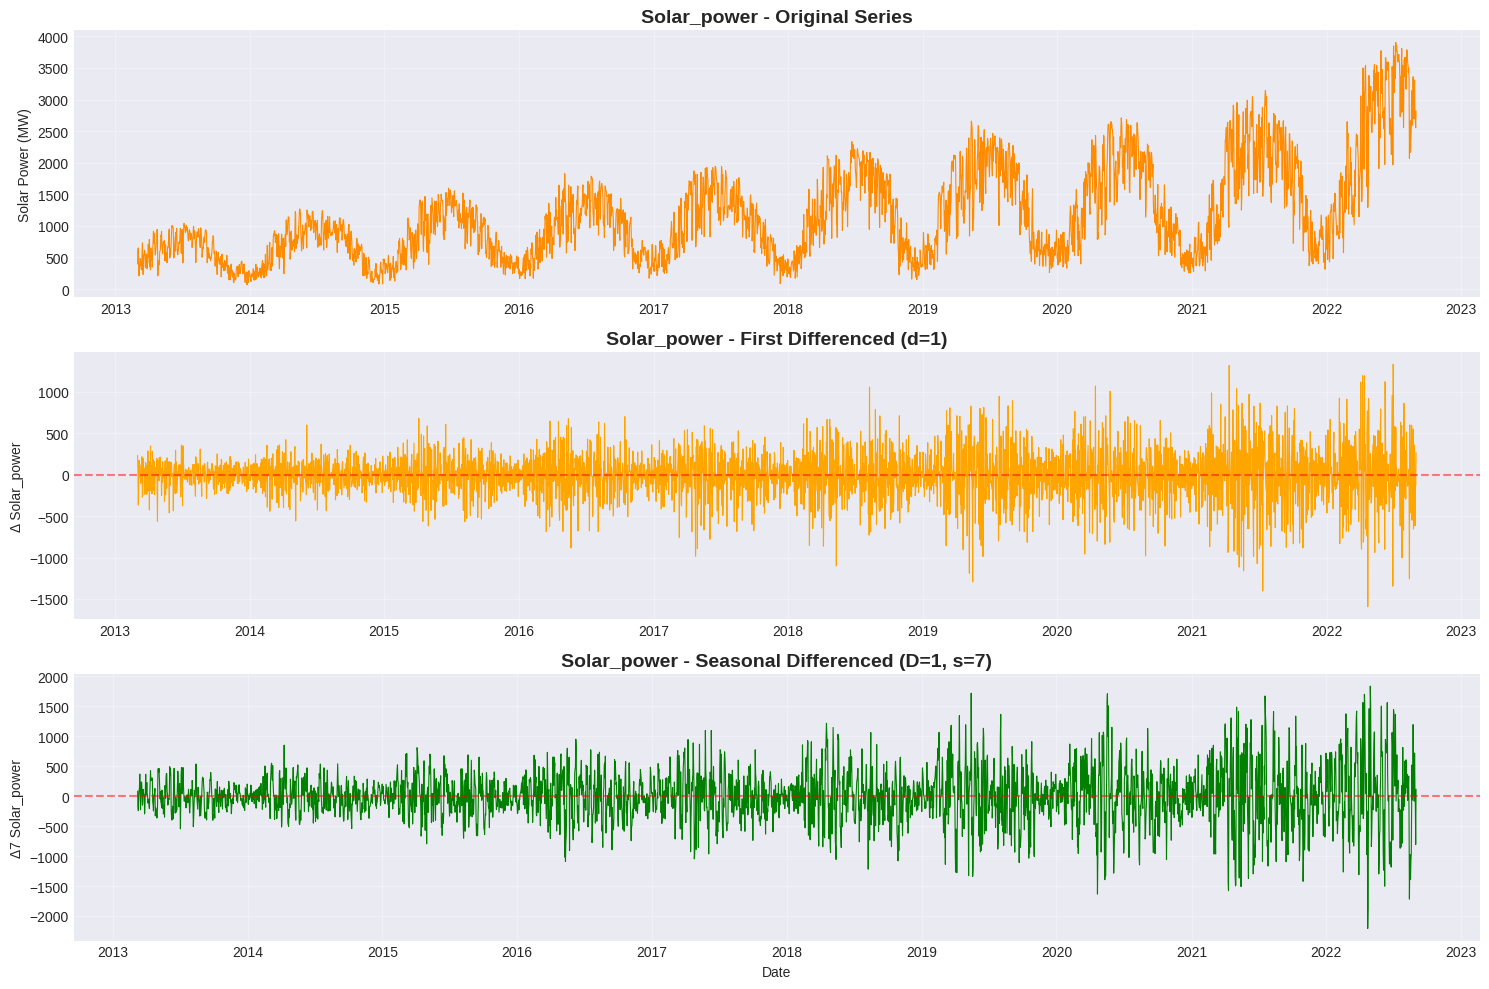

In [11]:
# Plot Solar_power series
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Original series
axes[0].plot(train['Date'], train['Solar_power'], linewidth=0.8, color='darkorange')
axes[0].set_title('Solar_power - Original Series', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Solar Power (MW)')
axes[0].grid(True, alpha=0.3)

# First difference (d=1)
solar_diff1 = train['Solar_power'].diff().dropna()
axes[1].plot(train['Date'].iloc[1:], solar_diff1, linewidth=0.8, color='orange')
axes[1].set_title('Solar_power - First Differenced (d=1)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Δ Solar_power')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

# Seasonal difference (D=1, s=7)
solar_diff7 = train['Solar_power'].diff(7).dropna()
axes[2].plot(train['Date'].iloc[7:], solar_diff7, linewidth=0.8, color='green')
axes[2].set_title('Solar_power - Seasonal Differenced (D=1, s=7)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Δ7 Solar_power')
axes[2].set_xlabel('Date')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# ADF test for Solar_power
adf_solar, conclusion_solar = run_stationarity_tests(train['Solar_power'], 'Solar_power (Original)')
adf_solar_d1, conclusion_solar_d1 = run_stationarity_tests(train['Solar_power'].diff(), 'Solar_power (d=1)')
adf_solar_D1, conclusion_solar_D1 = run_stationarity_tests(train['Solar_power'].diff(7), 'Solar_power (D=1, s=7)')
solar_diff_both = train['Solar_power'].diff().diff(7)
adf_solar_both, conclusion_solar_both = run_stationarity_tests(solar_diff_both, 'Solar_power (d=1, D=1, s=7)')


STATIONARITY TESTS: Solar_power (Original)

Augmented Dickey-Fuller Test:
  ADF Statistic: -2.295495
  p-value: 0.173425
  Critical values:
    1%: -3.432245
    5%: -2.862377
    10%: -2.567216
  => x NON-STATIONARY (p=> 0.05)

────────────────────────────────────────────────────────────────────────────────
CONCLUSION:
  Test indicate NON-STATIONARITY
────────────────────────────────────────────────────────────────────────────────

STATIONARITY TESTS: Solar_power (d=1)

Augmented Dickey-Fuller Test:
  ADF Statistic: -21.918540
  p-value: 0.000000
  Critical values:
    1%: -3.432245
    5%: -2.862377
    10%: -2.567216
  => o STATIONARY (p=< 0.05)

────────────────────────────────────────────────────────────────────────────────
CONCLUSION:
  Test indicate STATIONARITY
────────────────────────────────────────────────────────────────────────────────

STATIONARITY TESTS: Solar_power (D=1, s=7)

Augmented Dickey-Fuller Test:
  ADF Statistic: -10.120855
  p-value: 0.000000
  Critical valu

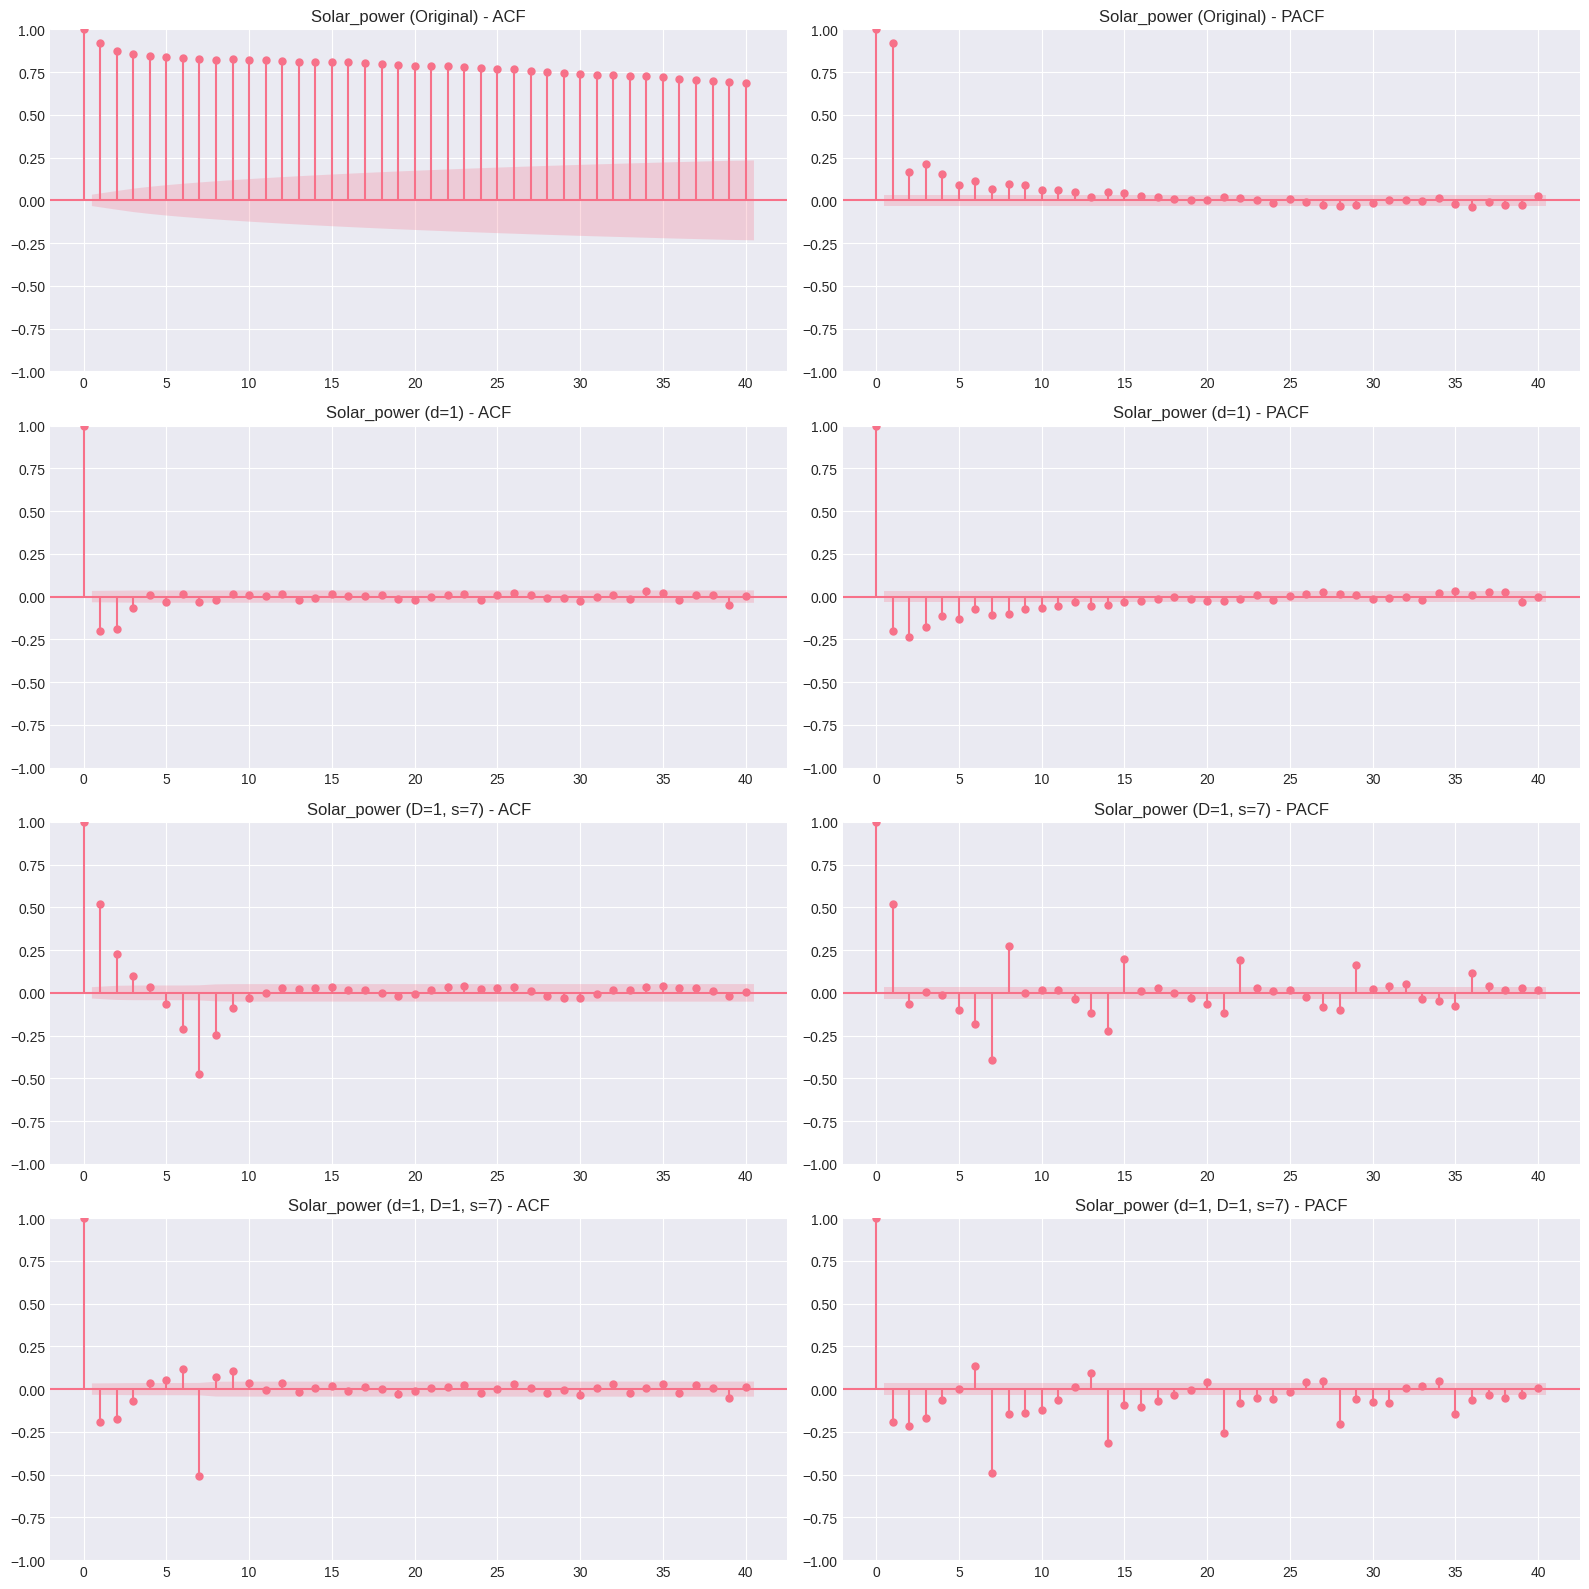

In [13]:
# ACF and PACF plots for Solar_power
fig, axes = plt.subplots(4, 2, figsize=(16, 16))

# Original series
plot_acf(train['Solar_power'].dropna(), ax=axes[0, 0], lags=40, title='Solar_power (Original) - ACF')
plot_pacf(train['Solar_power'].dropna(), ax=axes[0, 1], lags=40, title='Solar_power (Original) - PACF', method='ywm')

# First difference (d=1)
plot_acf(train['Solar_power'].diff().dropna(), ax=axes[1, 0], lags=40, title='Solar_power (d=1) - ACF')
plot_pacf(train['Solar_power'].diff().dropna(), ax=axes[1, 1], lags=40, title='Solar_power (d=1) - PACF', method='ywm')

# Seasonal difference (D=1, s=7)
plot_acf(train['Solar_power'].diff(7).dropna(), ax=axes[2, 0], lags=40, title='Solar_power (D=1, s=7) - ACF')
plot_pacf(train['Solar_power'].diff(7).dropna(), ax=axes[2, 1], lags=40, title='Solar_power (D=1, s=7) - PACF', method='ywm')

# Both differences (d=1, D=1, s=7)
plot_acf(train['Solar_power'].diff().diff(7).dropna(), ax=axes[3, 0], lags=40, title='Solar_power (d=1, D=1, s=7) - ACF')
plot_pacf(train['Solar_power'].diff().diff(7).dropna(), ax=axes[3, 1], lags=40, title='Solar_power (d=1, D=1, s=7) - PACF', method='ywm')

plt.tight_layout()
plt.show()

In [14]:
# Decision for Solar_power: d and D
print("\n" + "=" * 80)
print("DIFFERENCING DECISION FOR SOLAR_POWER")
print("=" * 80)

print("\nSummary of stationarity tests:")
print(f"  Original (d=0, D=0): {conclusion_solar}")
print(f"  First diff (d=1): {conclusion_solar_d1}")
print(f"  Seasonal diff (D=1): {conclusion_solar_D1}")
print(f"  Both (d=1, D=1): {conclusion_solar_both}")

print("\n" + "-" * 80)
print("RECOMMENDATION:")
print("-" * 80)

if conclusion_solar == "stationary":
    print("  Solar_power appears stationary => d=0, D=0")
    d_solar_rec = 0
    D_solar_rec = 0
elif conclusion_solar_d1 == "stationary" and conclusion_solar_D1 != "stationary":
    print("  First differencing achieves stationarity => d=1, D=0")
    d_solar_rec = 1
    D_solar_rec = 0
elif conclusion_solar_D1 == "stationary" and conclusion_solar_d1 != "stationary":
    print("  Seasonal differencing achieves stationarity => d=0, D=1")
    d_solar_rec = 0
    D_solar_rec = 1
elif conclusion_solar_both == "stationary":
    print("  Both differencing needed => d=1, D=1")
    print("  WARNING: Check for over-differencing in ACF plots.")
    d_solar_rec = 1
    D_solar_rec = 1
else:
    print("  Tests are inconclusive. Solar power has daily cycles:")
    print("  Trying d=0, D=0 first (cyclical stationarity may exist)")
    d_solar_rec = 0
    D_solar_rec = 0

print(f"\n  ok CHOSEN FOR SOLAR_POWER: d={d_solar_rec}, D={D_solar_rec}, s=7")
print("=" * 80)


DIFFERENCING DECISION FOR SOLAR_POWER

Summary of stationarity tests:
  Original (d=0, D=0): non-stationary
  First diff (d=1): stationary
  Seasonal diff (D=1): stationary
  Both (d=1, D=1): stationary

--------------------------------------------------------------------------------
RECOMMENDATION:
--------------------------------------------------------------------------------
  Both differencing needed => d=1, D=1

  ok CHOSEN FOR SOLAR_POWER: d=1, D=1, s=7


## Summary of Differencing Decisions

In [15]:
# Print summary table
print("\n" + "=" * 80)
print("FINAL DIFFERENCING PARAMETERS FOR THREE SARIMAX MODELS")
print("=" * 80)

summary_df = pd.DataFrame({
    'Target Variable': ['Load', 'Wind_power', 'Solar_power'],
    'd (non-seasonal)': [d_load_rec, d_wind_rec, d_solar_rec],
    'D (seasonal)': [D_load_rec, D_wind_rec, D_solar_rec],
    's (period)': [7, 7, 7]
})

print("\n")
print(summary_df.to_string(index=False))
print("\n" + "=" * 80)

print("\nNOTES:")
print("  • All models use weekly seasonality (s=7)")
print("  • These parameters will be used in SARIMAX(p,d,q)(P,D,Q,s) models")
print("  • Next step: Grid search over p, q, P, Q parameters")
print("  • Final reconstruction: Net_demand = Load - Solar_power - Wind_power")
print("=" * 80)


FINAL DIFFERENCING PARAMETERS FOR THREE SARIMAX MODELS


Target Variable  d (non-seasonal)  D (seasonal)  s (period)
           Load                 0             0           7
     Wind_power                 0             0           7
    Solar_power                 1             1           7


NOTES:
  • All models use weekly seasonality (s=7)
  • These parameters will be used in SARIMAX(p,d,q)(P,D,Q,s) models
  • Next step: Grid search over p, q, P, Q parameters
  • Final reconstruction: Net_demand = Load - Solar_power - Wind_power


## Step 5.2: Model Selection and Training

### 5.2.1 Load Model

In [16]:
import itertools
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load data
train_path = '../Data/train.csv'
test_path = '../Data/test.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# Convert Date to datetime
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

train = train.set_index("Date").sort_index()
test = test.set_index("Date").sort_index()

In [17]:

# Target series
y_train = train["Load"]
y_test = test["Load.1"]  # must exist: true Load in test for rolling updates


In [18]:
p_values = [0, 1, 2]
q_values = [0, 1, 2]
P_values = [0, 1, 2]
Q_values = [0, 1, 2]
seasonal_period = 7

best_aic = float("inf")
best_order = None
best_seasonal_order = None
aic_results = []

for p, q in itertools.product(p_values, q_values):
    order = (p, 0, q)
    for P, Q in itertools.product(P_values, Q_values):
        seasonal_order = (P, 0, Q, seasonal_period)
        try:
            model = SARIMAX(
                y_train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            res = model.fit(disp=False)
            aic = res.aic
            aic_results.append((order, seasonal_order, aic))

            if aic < best_aic:
                best_aic = aic
                best_order = order
                best_seasonal_order = seasonal_order
        except Exception:
            # Skip non‑convergent / invalid specifications
            continue

print("Best SARIMAX orders by AIC:")
print(f"  order={best_order}, seasonal_order={best_seasonal_order}, AIC={best_aic:.2f}")


Best SARIMAX orders by AIC:
  order=(1, 0, 2), seasonal_order=(1, 0, 2, 7), AIC=62214.04


In [19]:
best_model = SARIMAX(
    y_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
best_res = best_model.fit(disp=False)
print(best_res.summary())


                                     SARIMAX Results                                     
Dep. Variable:                              Load   No. Observations:                 3471
Model:             SARIMAX(1, 0, 2)x(1, 0, 2, 7)   Log Likelihood              -31100.020
Date:                           Mon, 09 Mar 2026   AIC                          62214.039
Time:                                   20:34:23   BIC                          62257.070
Sample:                               03-02-2013   HQIC                         62229.407
                                    - 09-01-2022                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9076      0.007    139.340      0.000       0.895       0.920
ma.L1          0.2079      0.012     16.943

In [20]:
# Fast rolling forecast without full re-fit at each step
rolling_forecasts = []

# Start from the model already fit on y_train (best_res from previous cell)
res_roll = best_res

# True observed Load values in test used for state updates
y_test = test["Load.1"]

for idx, y_true in y_test.items():
    # One-step-ahead forecast from current filtered state
    y_hat = float(res_roll.forecast(steps=1).iloc[0])
    rolling_forecasts.append(y_hat)

    # Update only the latent state with the new true observation (no parameter re-estimation)
    new_obs = pd.Series([y_true], index=[idx], name=y_train.name)
    res_roll = res_roll.append(new_obs, refit=False)

print(f"Generated {len(rolling_forecasts)} rolling forecasts.")

Generated 395 rolling forecasts.


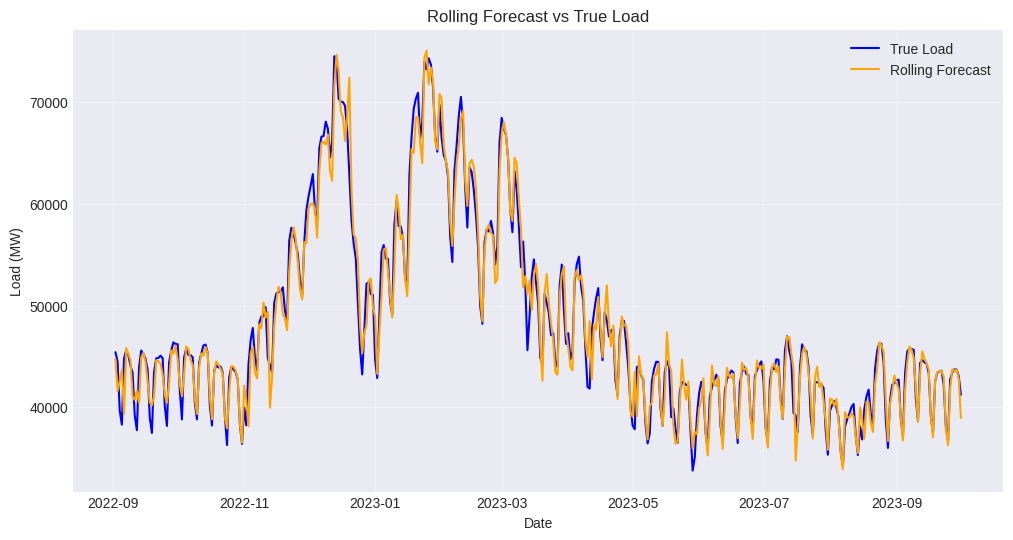

In [21]:
#show graph true value and forecast
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='True Load', color='blue')
plt.plot(y_test.index, rolling_forecasts, label='Rolling Forecast', color='orange')
plt.title('Rolling Forecast vs True Load')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
y_train_sol = train["Solar_power"]  
y_test_sol = test["Solar_power.1"]  # must exist: true Solar_power in test for rolling updates

In [ ]:
p_values = [1, 2]
q_values = [1, 2]
P_values = [1, 2]
Q_values = [1, 2]
seasonal_period = 7

best_aic_sol = float("inf")
best_order_sol = None
best_seasonal_order_sol = None
aic_results_sol = []

for p, q in itertools.product(p_values, q_values):
    order = (p, 0, q)
    for P, Q in itertools.product(P_values, Q_values):
        seasonal_order = (P, 0, Q, seasonal_period)
        try:
            model = SARIMAX(
                y_train_sol,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            res = model.fit(disp=False)
            aic = res.aic
            aic_results_sol.append((order, seasonal_order, aic))

            if aic < best_aic_sol:
                best_aic_sol = aic
                best_order_sol = order
                best_seasonal_order_sol = seasonal_order
        except Exception:
            # Skip non‑convergent / invalid specifications
            continue

print("Best SARIMAX orders by AIC:")
print(f"  order={best_order_sol}, seasonal_order={best_seasonal_order_sol}, AIC={best_aic_sol:.2f}")

KeyboardInterrupt: 

In [ ]:
best_model_sol = SARIMAX(
    y_train_sol,
    order=best_order_sol,
    seasonal_order=best_seasonal_order_sol,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
best_res_sol = best_model.fit(disp=False)
print(best_res_sol.summary())


In [ ]:
# Fast rolling forecast without full re-fit at each step
rolling_forecasts_sol = []

# Start from the model already fit on y_train (best_res from previous cell)
res_roll_sol = best_res_sol

# True observed Load values in test used for state updates
y_test_sol = test["Load.1"]

for idx, y_true in y_test_sol.items():
    # One-step-ahead forecast from current filtered state
    y_hat = float(res_roll_sol.forecast(steps=1).iloc[0])
    rolling_forecasts_sol.append(y_hat)

    # Update only the latent state with the new true observation (no parameter re-estimation)
    new_obs = pd.Series([y_true], index=[idx], name=y_train_sol.name)
    res_roll_sol = res_roll_sol.append(new_obs, refit=False)

print(f"Generated {len(rolling_forecasts_sol)} rolling forecasts.")

In [ ]:
#show graph true value and forecast
plt.figure(figsize=(12, 6))
plt.plot(y_test_sol.index, y_test_sol.values, label='True Solar', color='blue')
plt.plot(y_test_sol.index, rolling_forecasts_sol, label='Rolling Forecast', color='orange')
plt.title('Rolling Forecast vs True Solar')
plt.xlabel('Date')
plt.ylabel('Solar (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Future Direction

Possible extension explored: model Solar with a GAM-style approach using date, nebulosity, temperature, seasonal position (`toy`), and `solar.1` lag.